# RAGの性能評価結果の可視化

## ライブラリのインポート

In [1]:
import sys
from pathlib import Path
import pandas as pd
from IPython.display import Image as IPImage, display, HTML
import pandas as pd
import re
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_ollama import ChatOllama
import os
from dotenv import load_dotenv
import difflib
import html
import matplotlib.pyplot as plt
import pandas as pd

# プロジェクトパスを追加
current_dir = Path.cwd()
print(f"📁 現在のディレクトリ: {current_dir}")

# notebooks/ から プロジェクトルート へ
project_root = current_dir.parent
python_path = project_root / 'python'

print(f"📂 プロジェクトルート: {project_root}")
print(f"🐍 Pythonパス: {python_path}")

# パスを先頭に追加
sys.path.insert(0, str(python_path))

# モジュールインポート
try:
    from visualize.visualize import VisualizationGenerator
    print("✅ モジュールインポート成功")
except ImportError as e:
    print(f"❌ インポートエラー: {e}")
    print("パスを確認してください")

📁 現在のディレクトリ: /mnt/data-sda1/play-ground/g_hayate/25_isco4_dev/notebooks
📂 プロジェクトルート: /mnt/data-sda1/play-ground/g_hayate/25_isco4_dev
🐍 Pythonパス: /mnt/data-sda1/play-ground/g_hayate/25_isco4_dev/python
✅ モジュールインポート成功


In [2]:
SUMMARY_FILE = project_root / "outputs" / "summary.xlsx"
GEMINI_RESULTS_DIR = project_root / "outputs" / "external" / "gemini"
OLLAMA_RESULTS_DIR = project_root / "outputs" / "external" / "ollama"
PLOT_DIR = project_root / "outputs" / "plots"
EVALUATOR_LLM = "gemma3:12b"

In [3]:
# Gemini LLMモデル名のリスト
GEMINI_LLM_MODELS = [
    "gemini-3-pro-preview",
    "gemini-3-flash-preview",
    "gemini-2.5-flash",
    "gemini-2.5-flash-lite",
    "gemini-2.5-pro",
]

In [4]:
load_dotenv()

True

## 1. データ読み込みと基本統計

### 1.1. summary.xlsxの表示

In [5]:
summary_df = pd.read_excel(SUMMARY_FILE)
summary_df

,llm,embedding_model,eval_n,hardware,llm.total_execution_time,rag.total_execution_time,llm.avg_response_relevancy,rag.avg_context_precision,rag.avg_context_recall,rag.avg_context_entities_recall,rag.avg_noise_sensitivity,rag.avg_response_relevancy,rag.avg_faithfulness
0,gemini-2.5-flash-lite,embeddinggemma:latest,10,CUDA | NVIDIA RTX 6000 Ada Generation (47GB) |...,00:00,00:00,0.410193,1.0,1,0.358333,0.155952,0.782795,0.968333
1,gemini-2.5-flash,embeddinggemma:latest,10,CUDA | NVIDIA RTX 6000 Ada Generation (47GB) |...,00:01,00:00,0.480375,1.0,1,0.433333,0.078992,0.795522,0.969118
2,gemini-2.5-pro,embeddinggemma:latest,10,CUDA | NVIDIA RTX 6000 Ada Generation (47GB) |...,00:03,00:01,0.419788,1.0,1,0.358333,0.093333,0.799657,0.926667
3,gemini-3-flash-preview,embeddinggemma:latest,10,CUDA | NVIDIA RTX 6000 Ada Generation (47GB) |...,00:01,00:00,0.494082,1.0,1,0.358333,0.231373,0.801155,0.882540
4,gemma3:12b,embeddinggemma:latest,10,CUDA | NVIDIA RTX 6000 Ada Generation (47GB) |...,00:01,00:00,0.691797,1.0,1,0.433333,0.100000,0.791100,0.821667
5,gemma3:1b,embeddinggemma:latest,10,CUDA | NVIDIA RTX 6000 Ada Generation (47GB) |...,00:00,00:00,0.259341,1.0,1,0.408333,0.247619,0.806591,0.782440
6,gemma3:4b,embeddinggemma:latest,10,CUDA | NVIDIA RTX 6000 Ada Generation (47GB) |...,00:00,00:00,0.635734,1.0,1,0.383333,0.136369,0.702864,0.834167
7,gemma3:27b,embeddinggemma:latest,10,CUDA | NVIDIA RTX 6000 Ada Generation (47GB) |...,00:02,00:00,0.615367,1.0,1,0.383333,0.191667,0.798325,0.993333
8,gpt-oss:120b,embeddinggemma:latest,10,CUDA | NVIDIA RTX 6000 Ada Generation (47GB) |...,00:16,00:04,0.744987,1.0,1,0.433333,0.187308,0.788938,0.702619
9,gemini-3-pro-preview,embeddinggemma:latest,10,CUDA | NVIDIA RTX 6000 Ada Generation (47GB) |...,00:04,00:05,0.295531,1.0,1,0.433333,0.132500,0.764998,0.962500


### 1.2. 基本統計量の算出

In [6]:
for file_path in GEMINI_RESULTS_DIR.glob("results_*.xlsx"):
    result_df = pd.read_excel(file_path)
    result_df['rag.negative_noise_sensitivity'] = result_df['rag.noise_sensitivity'].map(lambda x: -x)
    model_name = file_path.stem.removeprefix("results_")
    print(f"📊 {model_name}を使用したRAGの評価結果の統計:")
    display(result_df.describe())

for file_path in OLLAMA_RESULTS_DIR.glob("results_*.xlsx"):
    result_df = pd.read_excel(file_path)
    result_df['rag.negative_noise_sensitivity'] = result_df['rag.noise_sensitivity'].map(lambda x: -x)
    model_name = file_path.stem.removeprefix("results_")
    print(f"📊 {model_name}を使用したRAGの評価結果の統計:")
    display(result_df.describe())

📊 gemini-3-pro-previewを使用したRAGの評価結果の統計:


,llm.execution_time,rag.execution_time,llm.response_relevancy,rag.context_precision,rag.context_recall,rag.context_entities_recall,rag.noise_sensitivity,rag.response_relevancy,rag.faithfulness,rag.negative_noise_sensitivity
count,10.000000,10.000000,10.000000,10.0,10.0,10.000000,10.000000,10.000000,10.000000,10.000000
mean,29.456118,32.658275,0.295531,1.0,1.0,0.433333,0.132500,0.764998,0.962500,-0.132500
std,7.853079,41.862572,0.407024,0.0,0.0,0.316228,0.151456,0.073279,0.084369,0.151456
min,19.761175,5.880464,0.000000,1.0,1.0,0.000000,0.000000,0.614926,0.750000,-0.375000
25%,23.192359,8.961756,0.000000,1.0,1.0,0.208333,0.000000,0.719083,1.000000,-0.237500
50%,28.113768,12.115305,0.000000,1.0,1.0,0.500000,0.083333,0.784365,1.000000,-0.083333
75%,34.859138,26.684050,0.722356,1.0,1.0,0.625000,0.237500,0.820250,1.000000,-0.000000
max,44.239884,124.011560,0.887539,1.0,1.0,1.000000,0.375000,0.854546,1.000000,-0.000000


📊 gemini-2.5-flashを使用したRAGの評価結果の統計:


,llm.execution_time,rag.execution_time,llm.response_relevancy,rag.context_precision,rag.context_recall,rag.context_entities_recall,rag.noise_sensitivity,rag.response_relevancy,rag.faithfulness,rag.negative_noise_sensitivity
count,10.000000,10.000000,10.000000,10.0,10.0,10.000000,10.000000,10.000000,10.000000,10.000000
mean,10.273048,2.443911,0.480375,1.0,1.0,0.433333,0.078992,0.795522,0.969118,-0.078992
std,1.864955,1.192133,0.421423,0.0,0.0,0.316228,0.204585,0.091533,0.079178,0.204585
min,8.264615,1.481296,0.000000,1.0,1.0,0.000000,0.000000,0.647366,0.750000,-0.647059
25%,8.799821,1.715603,0.000000,1.0,1.0,0.208333,0.000000,0.766299,1.000000,0.000000
50%,9.841190,2.000749,0.676588,1.0,1.0,0.500000,0.000000,0.804355,1.000000,-0.000000
75%,11.274489,2.798888,0.836643,1.0,1.0,0.625000,0.000000,0.839737,1.000000,-0.000000
max,13.467421,5.466405,0.920398,1.0,1.0,1.000000,0.647059,0.921015,1.000000,-0.000000


📊 gemini-2.5-flash-liteを使用したRAGの評価結果の統計:


...

,llm.execution_time,rag.execution_time,llm.response_relevancy,rag.context_precision,rag.context_recall,rag.context_entities_recall,rag.noise_sensitivity,rag.response_relevancy,rag.faithfulness,rag.negative_noise_sensitivity
count,10.000000,10.000000,10.000000,10.0,10.0,10.000000,10.000000,10.000000,10.000000,10.000000
mean,3.059208,0.535483,0.635734,1.0,1.0,0.383333,0.136369,0.702864,0.834167,-0.136369
std,1.141595,0.306447,0.348709,0.0,0.0,0.249072,0.225637,0.262985,0.314771,0.225637
min,1.186938,0.327388,0.000000,1.0,1.0,0.000000,0.000000,0.000000,0.000000,-0.687500
25%,2.214237,0.364620,0.639537,1.0,1.0,0.208333,0.000000,0.706438,0.818750,-0.185714
50%,3.418489,0.448524,0.769436,1.0,1.0,0.500000,0.000000,0.756412,1.000000,-0.000000
75%,3.717162,0.521651,0.854804,1.0,1.0,0.500000,0.185714,0.823610,1.000000,-0.000000
max,4.968694,1.357358,0.914622,1.0,1.0,0.666667,0.687500,0.921015,1.000000,-0.000000


📊 gpt-oss:20bを使用したRAGの評価結果の統計:


,llm.execution_time,rag.execution_time,llm.response_relevancy,rag.context_precision,rag.context_recall,rag.context_entities_recall,rag.noise_sensitivity,rag.response_relevancy,rag.faithfulness,rag.negative_noise_sensitivity
count,10.000000,10.000000,10.000000,10.0,10.0,10.000000,10.000000,10.000000,10.000000,10.000000
mean,10.440854,2.246358,0.536914,1.0,1.0,0.408333,0.131667,0.784833,0.765952,-0.131667
std,3.439252,1.453505,0.379369,0.0,0.0,0.320229,0.214368,0.088692,0.231028,0.214368
min,4.759287,0.857834,0.000000,1.0,1.0,0.000000,0.000000,0.614940,0.333333,-0.666667
25%,8.597820,1.391581,0.143857,1.0,1.0,0.187500,0.000000,0.751740,0.666667,-0.200000
50%,10.121596,1.995054,0.727901,1.0,1.0,0.416667,0.000000,0.769538,0.725000,-0.000000
75%,12.261562,2.504495,0.821029,1.0,1.0,0.625000,0.200000,0.828152,1.000000,-0.000000
max,17.038628,5.838567,0.856852,1.0,1.0,1.000000,0.666667,0.921015,1.000000,-0.000000


📊 gpt-oss:120bを使用したRAGの評価結果の統計:


,llm.execution_time,rag.execution_time,llm.response_relevancy,rag.context_precision,rag.context_recall,rag.context_entities_recall,rag.noise_sensitivity,rag.response_relevancy,rag.faithfulness,rag.negative_noise_sensitivity
count,10.000000,10.000000,10.000000,10.0,10.0,10.000000,10.000000,10.000000,10.000000,10.000000
mean,96.696606,24.454589,0.744987,1.0,1.0,0.433333,0.187308,0.788938,0.702619,-0.187308
std,32.776698,11.909646,0.099288,0.0,0.0,0.316228,0.275006,0.089053,0.299682,0.275006
min,51.853193,13.106977,0.581697,1.0,1.0,0.000000,0.000000,0.626656,0.285714,-0.750000
25%,76.131566,15.995241,0.708897,1.0,1.0,0.208333,0.000000,0.745390,0.413690,-0.367308
50%,89.567955,19.277928,0.755488,1.0,1.0,0.500000,0.000000,0.781799,0.733333,-0.000000
75%,125.573250,29.542547,0.799664,1.0,1.0,0.625000,0.367308,0.861684,1.000000,-0.000000
max,146.582282,50.410052,0.918094,1.0,1.0,1.000000,0.750000,0.913663,1.000000,-0.000000


### 1.3. 良例と悪例を表示

In [7]:
def _initialize_evaluator_llm(model_name):
    """評価用LLMを初期化する"""
    if model_name in GEMINI_LLM_MODELS:
        # Gemini APIを使用
        api_key = os.getenv("GEMINI_API_KEY")
        return ChatGoogleGenerativeAI(
            model=model_name,
            google_api_key=api_key,
        )
    else:
        # Ollamaを使用
        return ChatOllama(model=model_name)

In [8]:
def indent(text, n_spaces=2):
    prefix = " " * n_spaces
    return "\n".join(prefix + line for line in str(text).splitlines())

def generate_analysis(evaluator_llm, query, context, ground_truth, rag_answer, response_relevancy, faithfulness, noise_sensitivity):
    prompt = f"""RAGへのクエリと、コンテキスト、正答例、RAGの回答、Ragasによる評価結果を示します。100文字程度で結果を考察してください。
質問:
{indent(query)}
コンテキスト: 
{indent(context)}
正答例: 
{indent(ground_truth)}
回答: 
{indent(rag_answer)}
Response Relevancy: 
{indent(response_relevancy)}
Faithfulness: 
{indent(faithfulness)}
Noise Sensitivity: 
{indent(noise_sensitivity)}

Noise Sensitivity(relevant)の計算手順は以下です:
1. 評価用LLMが、各チャンクが理想的な回答を推測できるか検証します。推測できれば、理想的な回答と"関連のある"チャンクになります。
2. 評価用LLMがRAGの回答に含まれる全ての主張を特定します。
3. 各主張が"関連のある"チャンクから推測できるかを検証します。
4. 各主張が"理想的な回答"に含まれるかどうかを検証します。
5. 次の式を使用して、"Noise Sensitivity (relevant)スコアを計算します。
$$Noise Sensitivity (relevant) Score = \\frac{{関連のあるチャンクから推測できる かつ 理想的な回答に含まれない 主張の数}}{{RAGの回答に含まれる全ての主張の数}}$$

Respose Relevancyの計算手順は以下です:
6. 評価用LLMを用いて、RAGの回答の内容を元に、元の質問を推測します。（デフォルトでは3つ推測します。）
7. 評価用埋め込みモデルを用いて、推測した各質問と、実際の元の質問をベクトルに変換し、両ベクトルのコサイン類似度を計算します。
8. 全てのコサイン類似度スコアを平均します。

Faithfulnessの計算手順は以下です:
1. 評価用LLMが回答に含まれるすべての主張を特定します。
2. 評価用LLMが各主張が取得されたコンテキストから推測できるかどうかを確認します。
3. 次の式を使用してFaithfulnessスコアを計算します。
$$Faithfulness Score = \\frac{{回答に含まれ、コンテキストから推測できる主張の数}}{{回答に含まれる主張の数}}$$
"""

    result = evaluator_llm.invoke(prompt)
    return result.content

In [9]:
def diff_highlight(old: str, new: str) -> str:
    matcher = difflib.SequenceMatcher(None, old, new)
    result = []

    for tag, i1, i2, j1, j2 in matcher.get_opcodes():
        if tag == "equal":
            result.append(html.escape(new[j1:j2]))

        elif tag == "insert":
            result.append(
                f"<span class='diff-insert'>{html.escape(new[j1:j2])}</span>"
            )

        elif tag == "replace":
            result.append(
                f"<span class='diff-replace'>{html.escape(new[j1:j2])}</span>"
            )

        elif tag == "delete":
            result.append(
                f"<span class='diff-delete'>{html.escape(old[i1:i2])}</span>"
            )

    return "".join(result)

In [30]:
def show_table(example_name, query, ground_truth, rag_answer, response_relevancy, faithfulness, noise_sensitivity, analysis):
    df = pd.DataFrame(
        {
            "row0": [
                f"{example_name}", 
                "クエリ", 
                "正答例", 
                "回答", 
                f"AI考察<br>({EVALUATOR_LLM})"
            ],
            "row1": [
                f"rag.noise_sensitivity={noise_sensitivity:.2f}",
                "query",
                "ground_truth",
                "rag_answer",
                "analysis",
            ],
            "row2": [
                f"rag.response_relevancy={response_relevancy:.2f}",
                "delete",
                "delete",
                "delete",
                "delete",
            ],
            "row3": [
                f"rag.faithfulness={faithfulness:.2f}",
                "delete",
                "delete",
                "delete",
                "delete",
            ],
        }
    )
    
    table_id = ""
    if "良例" in example_name:
        table_id = "good"
    else:
        table_id = "bad"
    
    style = f"""
    <style>
    .diff-replace {{
      background-color: #e3f2fd;
      color: #0d47a1;
      font-weight: bold;
    }}
    .diff-insert {{
      background-color: #e3f2fd;
      color: #0d47a1;
      font-weight: bold;
    }}
    .diff-delete {{
      text-decoration: line-through;
      background-color: #ffebee;
      color: #b71c1c;
      font-weight: bold;
    }}
    
    /* 内容セル */
    td {{
      text-align: left !important;
      white-space: pre-wrap !important;
      word-break: break-word;
      vertical-align: top;
    }}

    /* 1行目 */
    table#good tbody tr:first-child {{
      background-color: #e8f5e9 !important;
      color: #1b5e20 !important;
      font-weight: bold;
    }}
    table#bad tbody tr:first-child {{
      background-color: #fff3e0 !important;
      color: #e65100 !important;
      font-weight: bold;
    }}

    /* 1列目 */
    table tbody td:nth-child(1) {{
      font-weight: bold;
      text-align: center !important;
    }}
    </style>
    """

    query_html = query.replace("\n", "<br>"),
    ground_truth_html = ground_truth.replace("\n", "<br>"),
    rag_answer_html = diff_highlight(ground_truth, rag_answer).replace("\n", "<br>"),
    analysis_html = analysis.replace("\n", "<br>")

    df_html = df.to_html(escape=False, index=False, header=False, table_id=table_id)
    df_html = df_html.replace("<td>query</td>", f'<td colspan="3">{query_html}</td>')
    df_html = df_html.replace("<td>ground_truth</td>", f'<td colspan="3">{ground_truth_html}</td>')
    df_html = df_html.replace("<td>rag_answer</td>", f'<td colspan="3">{rag_answer_html}</td>')
    df_html = df_html.replace("<td>analysis</td>", f'<td colspan="3">{analysis_html}</td>')
    df_html = df_html.replace("<td>delete</td>", "")
    display(HTML(style + df_html))

In [31]:
def show_good_bad_examples(evaluator_llm, file_path, n=5):
    result_df = pd.read_excel(file_path)
    model_name = file_path.stem.removeprefix("results_")
    result_df['rag.negative_noise_sensitivity'] = result_df['rag.noise_sensitivity'].map(lambda x: -x)

    #### 良例n件の表示 ####
    
    print(f"📊 {model_name}の良例5件:")
    for i, values in enumerate(result_df.nlargest(n, ['rag.negative_noise_sensitivity', 'rag.response_relevancy', 'rag.faithfulness']).values):
        query = values[0]
        context = values[1]
        rag_answer = values[5]
        ground_truth = values[6]
        noise_sensitivity = values[11]
        response_relevancy = values[12]
        faithfulness = values[13]
        analysis = generate_analysis(evaluator_llm, query, context, ground_truth, rag_answer, response_relevancy, faithfulness, noise_sensitivity)
        show_table(f"良例{i+1}", query, ground_truth, rag_answer, response_relevancy, faithfulness, noise_sensitivity, analysis)

    #### 悪例n件の表示 ####
    
    print(f"📊 {model_name}の悪例5件:")
    for i, values in enumerate(result_df.nsmallest(n, ['rag.negative_noise_sensitivity', 'rag.response_relevancy', 'rag.faithfulness']).values):
        query = values[0]
        context = values[1]
        rag_answer = values[5]
        ground_truth = values[6]
        noise_sensitivity = values[11]
        response_relevancy = values[12]
        faithfulness = values[13]
        analysis = generate_analysis(evaluator_llm, query, context, ground_truth, rag_answer, response_relevancy, faithfulness, noise_sensitivity)
        show_table(f"悪例{i+1}", query, ground_truth, rag_answer, response_relevancy, faithfulness, noise_sensitivity, analysis)

In [32]:
evaluator_llm = _initialize_evaluator_llm(EVALUATOR_LLM)

for file_path in GEMINI_RESULTS_DIR.glob("results_*.xlsx"):
    show_good_bad_examples(evaluator_llm, file_path)

for file_path in OLLAMA_RESULTS_DIR.glob("results_*.xlsx"):
    show_good_bad_examples(evaluator_llm, file_path)

📊 gemini-3-pro-previewの良例5件:


📊 gemini-3-pro-previewの悪例5件:


📊 gemini-2.5-flashの良例5件:


📊 gemini-2.5-flashの悪例5件:


📊 gemini-2.5-flash-liteの良例5件:


...

📊 gemma3:4bの悪例5件:


📊 gpt-oss:20bの良例5件:


📊 gpt-oss:20bの悪例5件:


📊 gpt-oss:120bの良例5件:


📊 gpt-oss:120bの悪例5件:


## 2. 統計可視化

=== 可視化スクリプト ===

1. データの読み込み
   - summary.xlsx: 11件のモデル
   - results_*.xlsx: 11ファイル
     - gemini-3-pro-preview: 10件
     - gemini-2.5-flash: 10件
     - gemini-2.5-flash-lite: 10件
     - gemini-2.5-pro: 10件
     - gemini-3-flash-preview: 10件
     - gemma3:1b: 10件
     - gemma3:12b: 10件
     - gemma3:27b: 10件
     - gemma3:4b: 10件
     - gpt-oss:20b: 10件
     - gpt-oss:120b: 10件

2. グラフの生成
   - execution_time_comparison.png
   - noise_sensitivity_model_comparison.png
   - response_relevancy_comparison.png


/mnt/data-sda1/play-ground/g_hayate/25_isco4_dev/python/visualize/visualize.py:180: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(models, rotation=45, ha="right")


   - faithfulness_model_comparison.png
   - execution_time_boxplot.png


/mnt/data-sda1/play-ground/g_hayate/25_isco4_dev/python/visualize/visualize.py:180: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(models, rotation=45, ha="right")


   - noise_sensitivity_boxplot.png
   - response_relevancy_boxplot.png
   - faithfulness_boxplot.png

=== 完了: /mnt/data-sda1/play-ground/g_hayate/25_isco4_dev/outputs/plots に保存しました ===

📊 生成されたプロット:


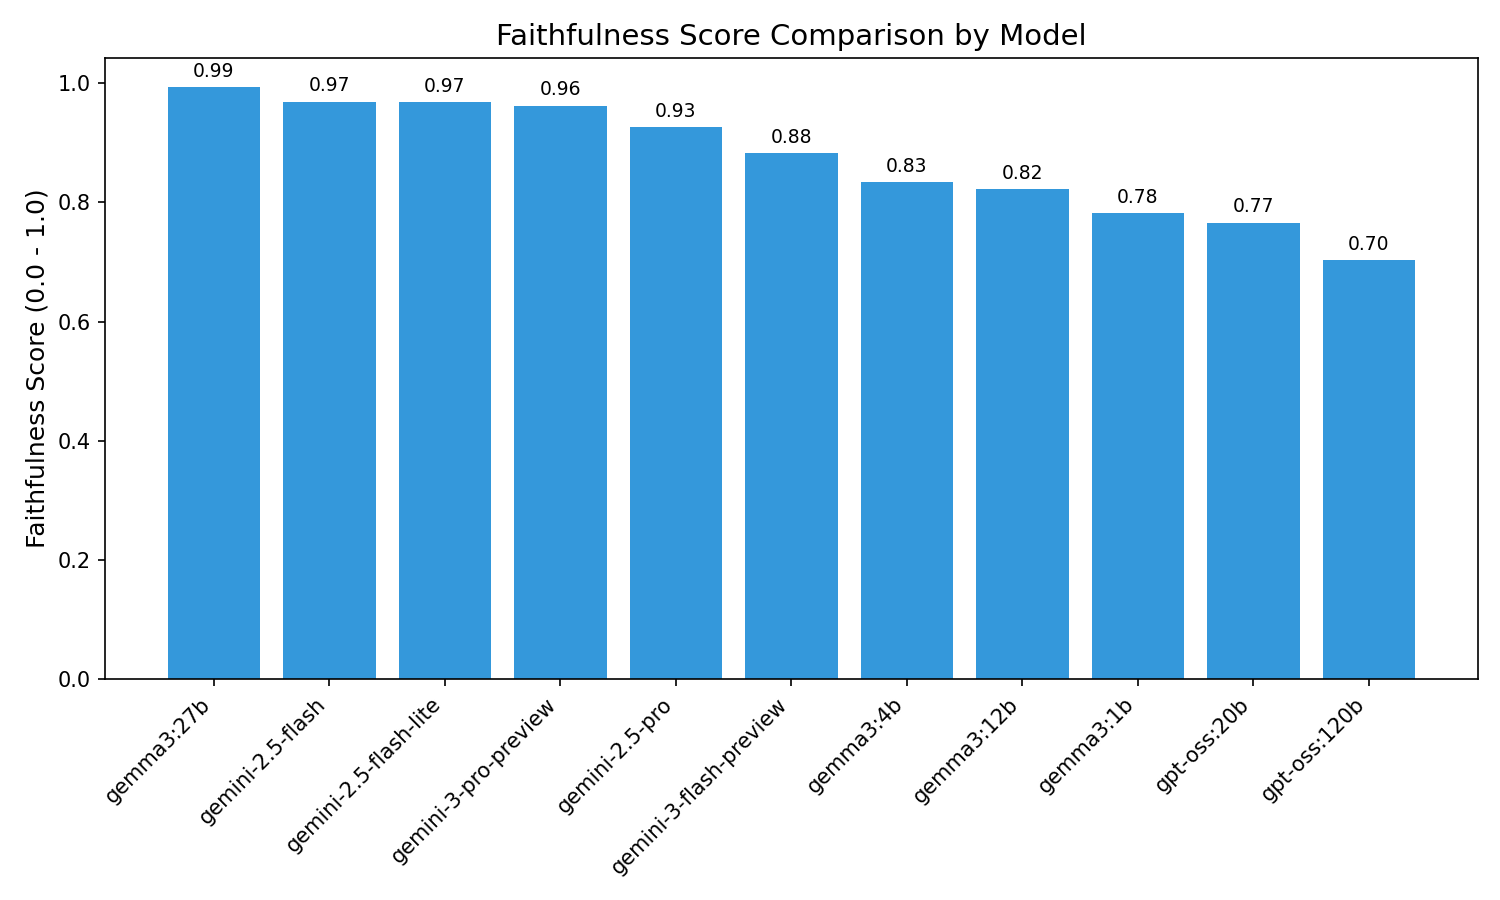

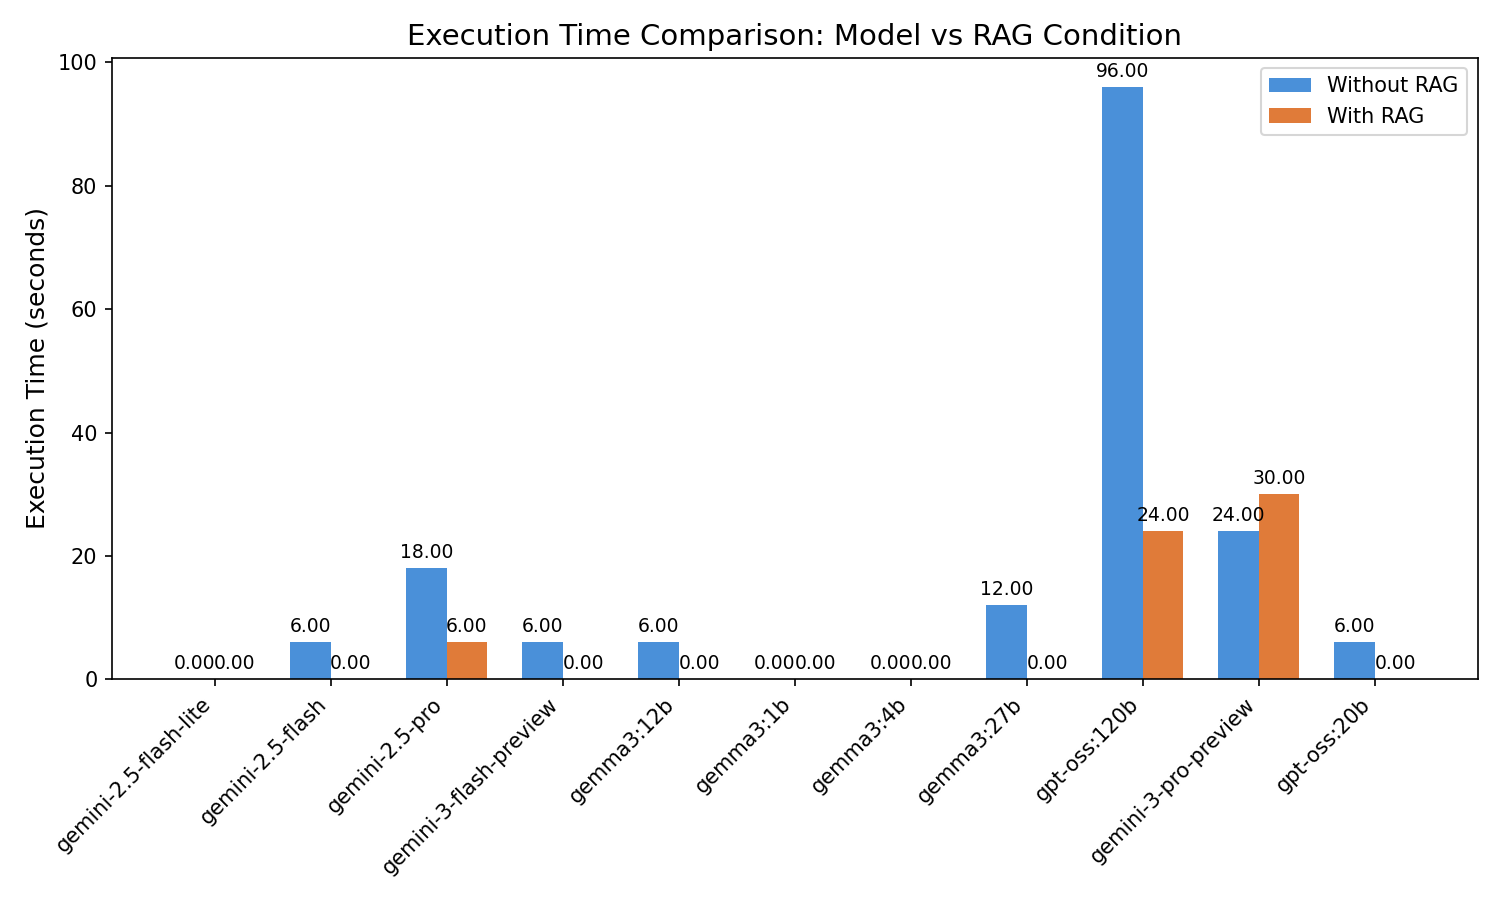

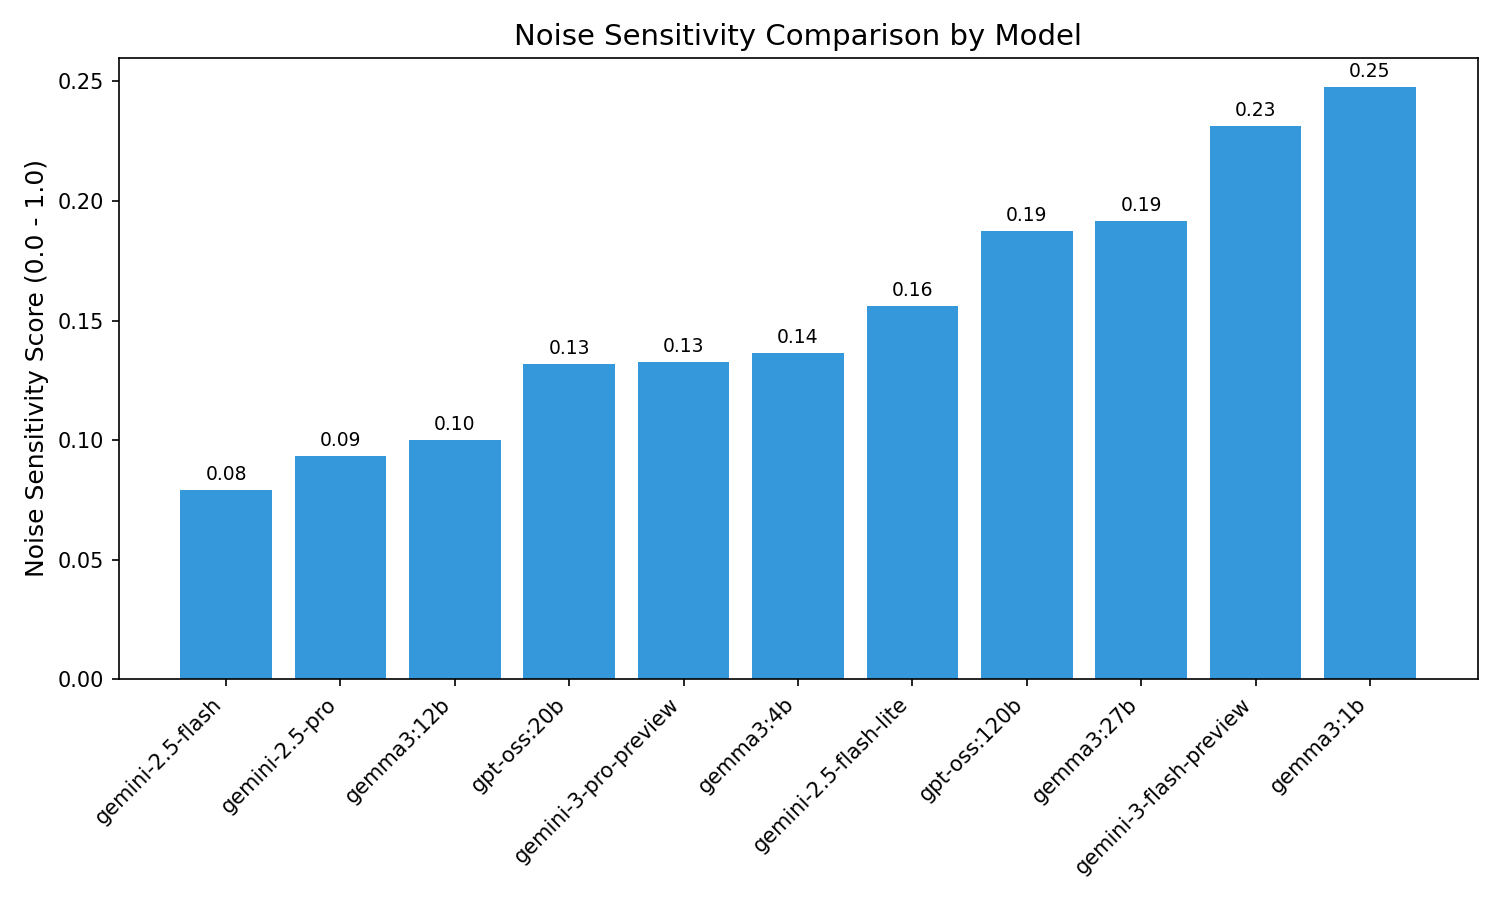

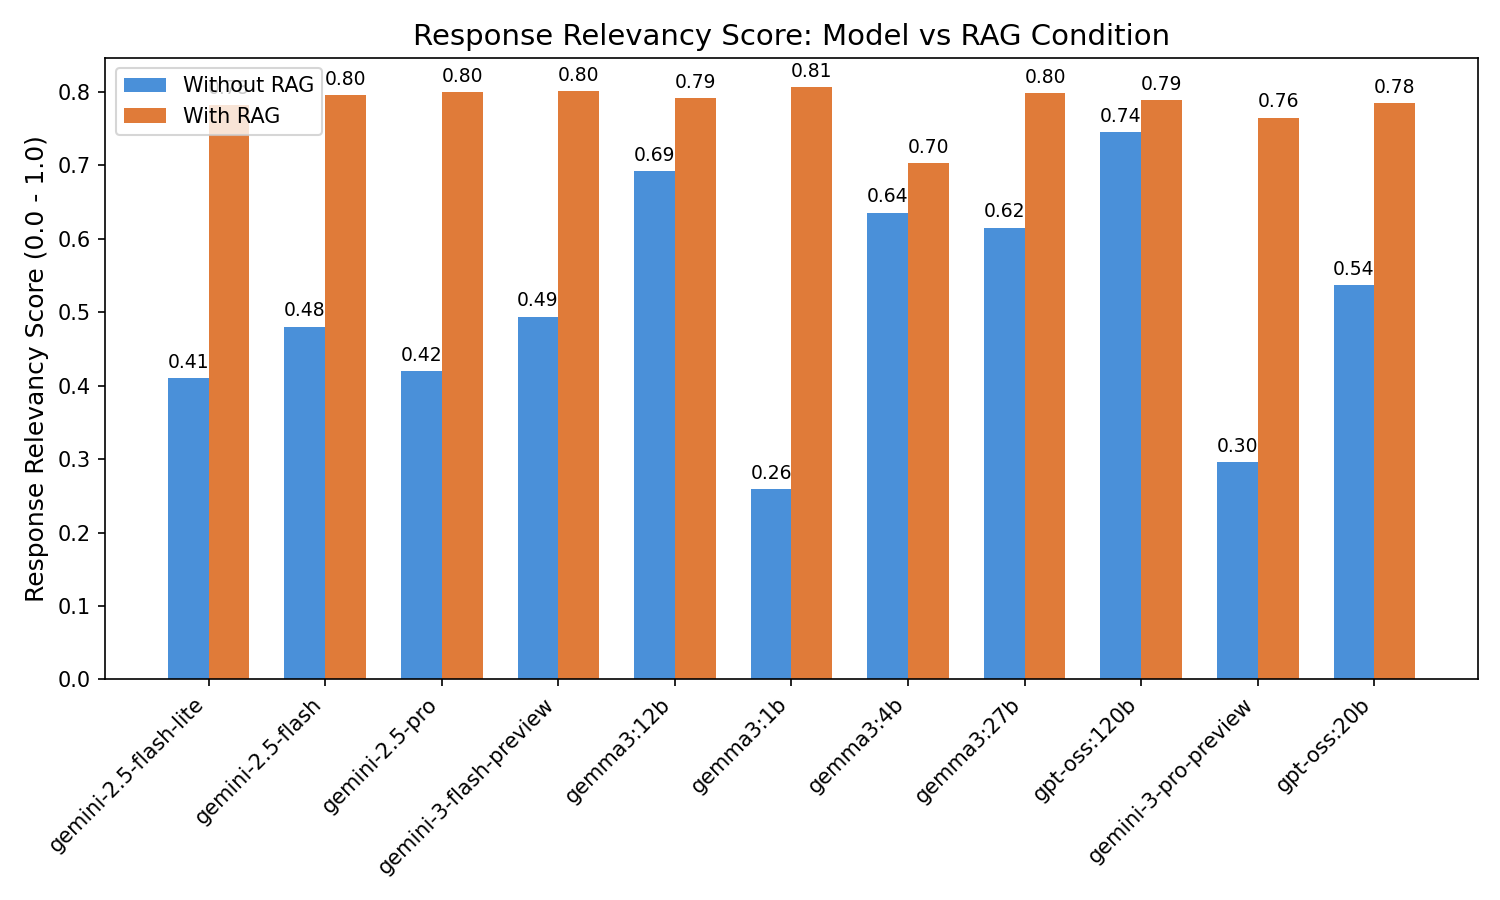

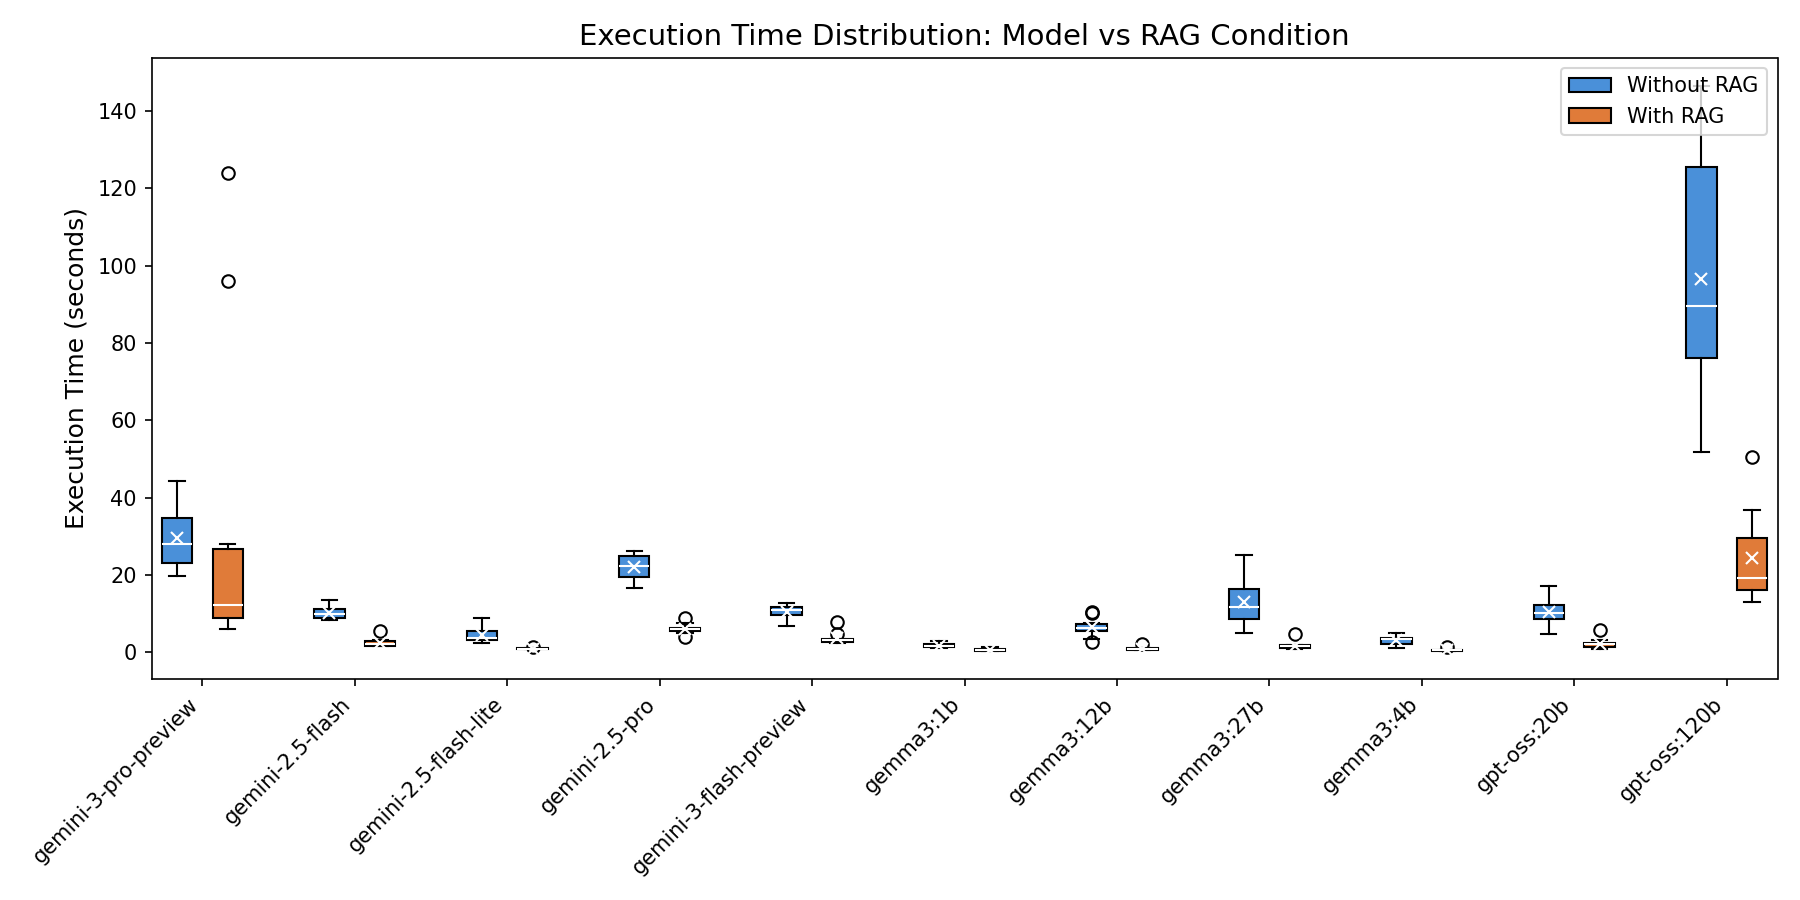

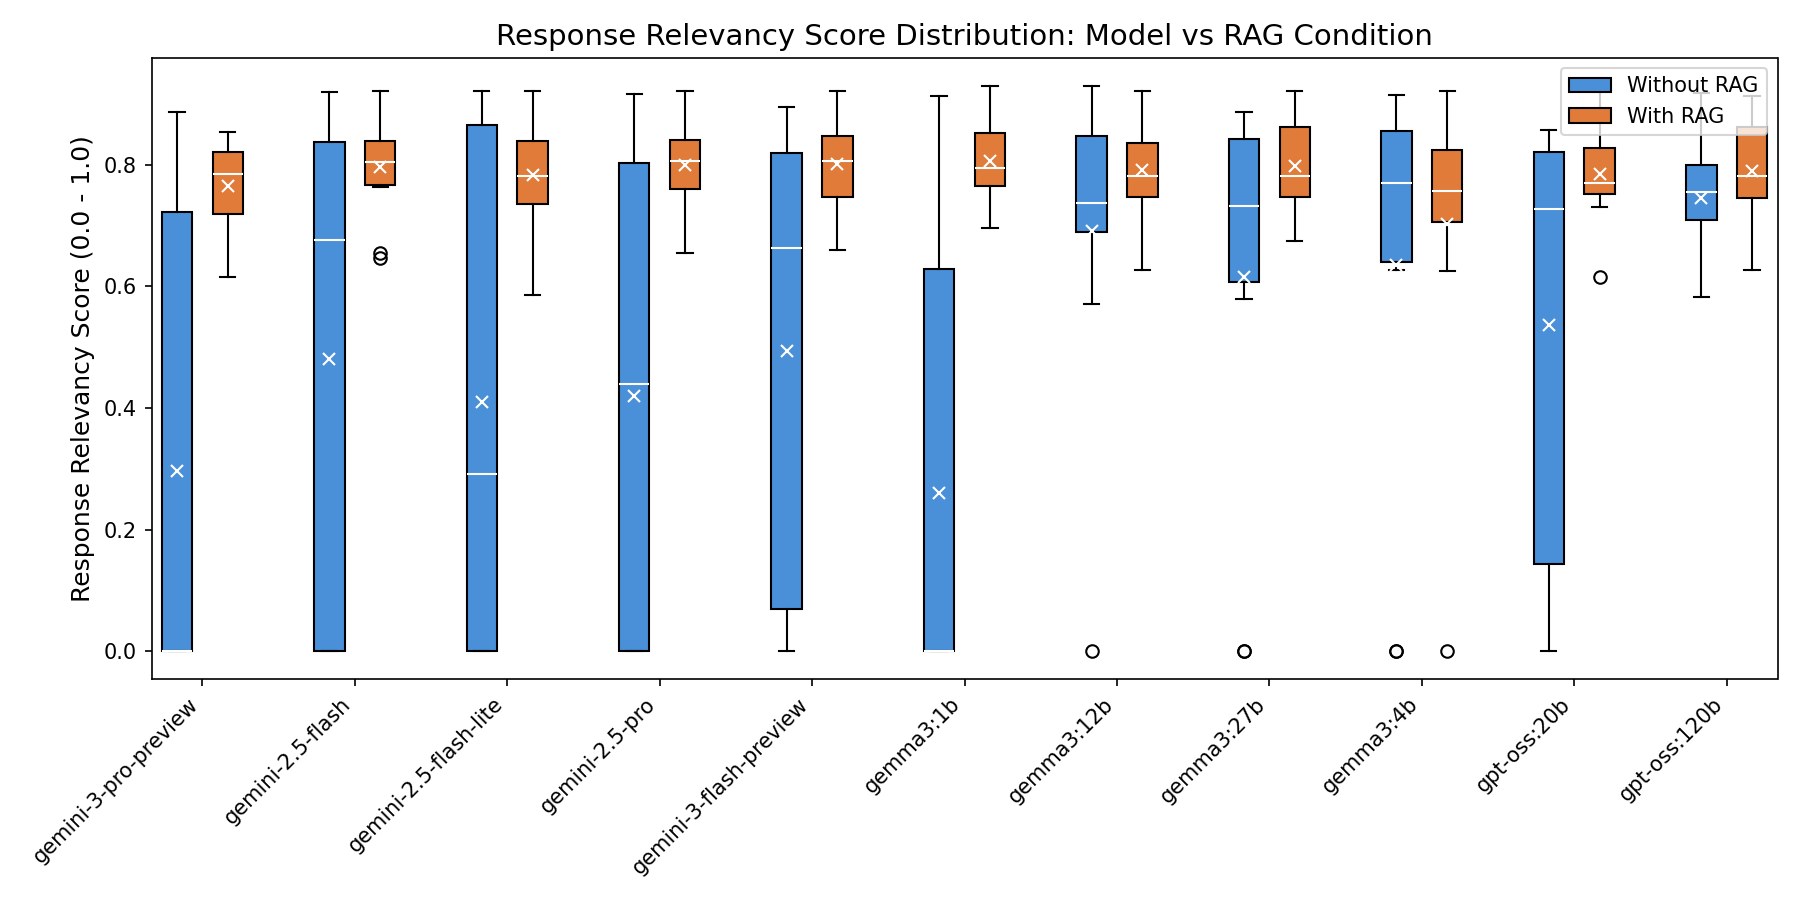

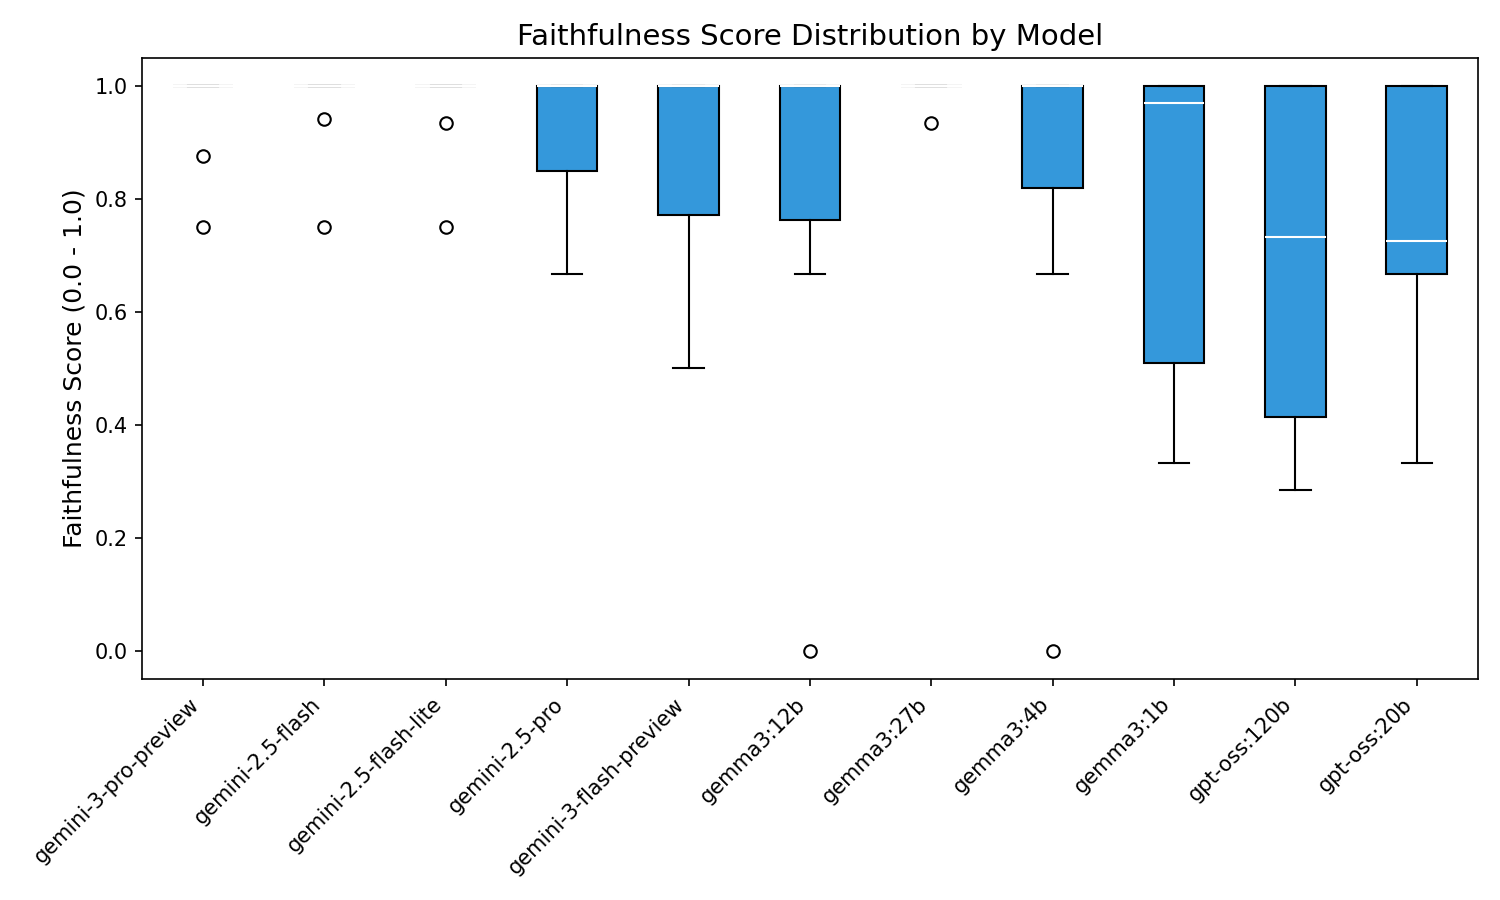

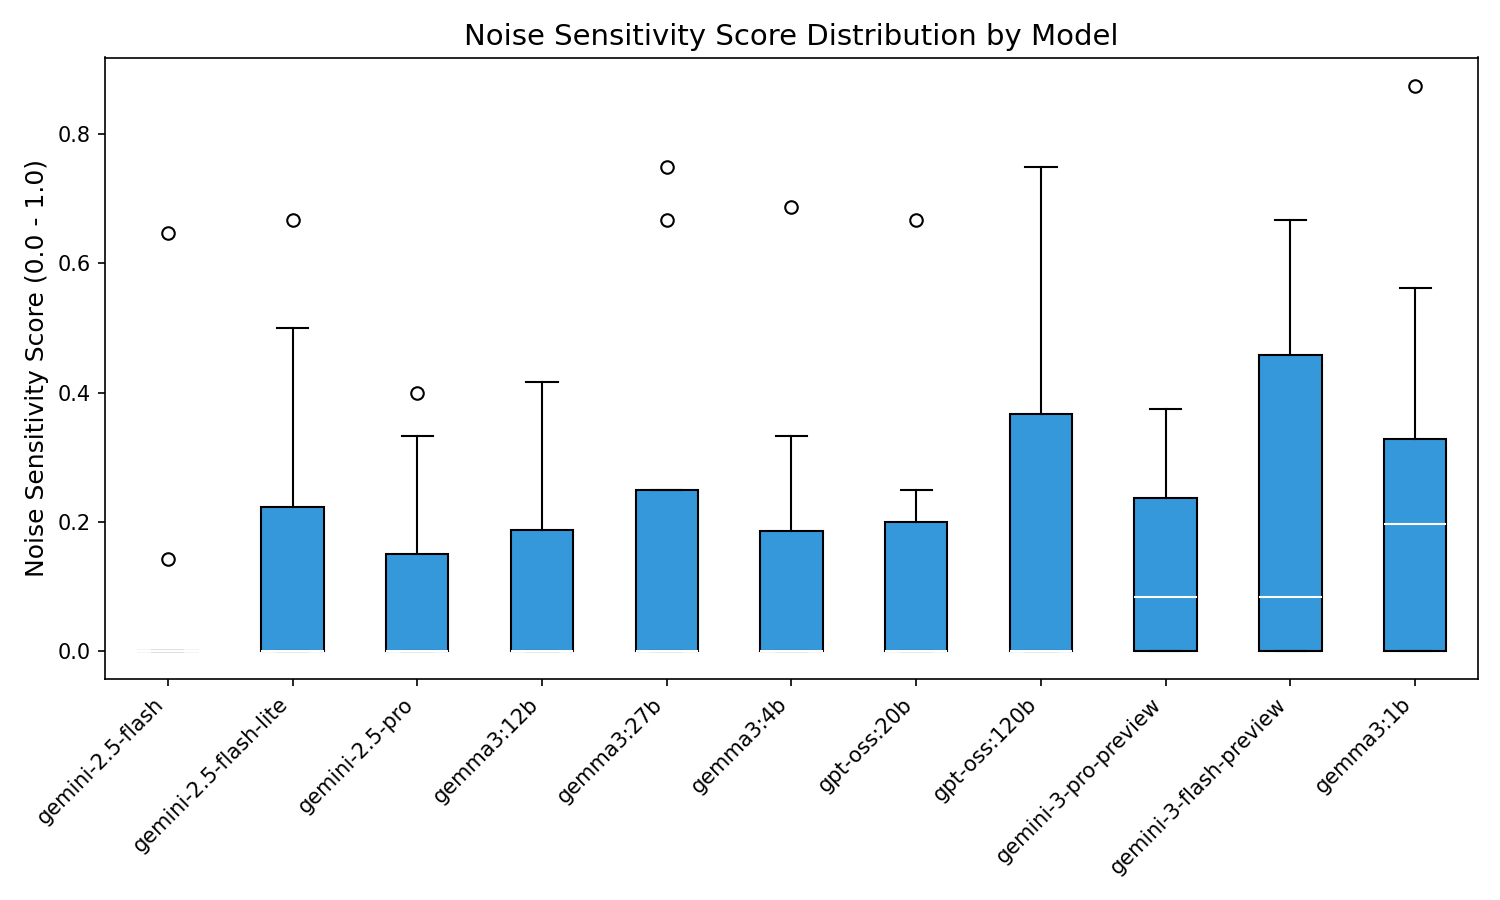

In [33]:
# 📊 統計プロット生成
generator = VisualizationGenerator()
generator.generate_all_visualizations()

# 📈 生成されたプロットを表示
print("\n📊 生成されたプロット:")
for plot_path in PLOT_DIR.glob("*.png"):
    display(IPImage(str(plot_path)))